# Workflow Pattern: Parallelization

### Workflow Pattern: Parallelization

Parallelization is a pattern where **multiple LLM tasks are executed at the same time** instead of one after another. This is useful when different parts of the task can be done **independently**, allowing for faster processing and better system throughput.

#### Use Cases:
- Summarizing different sections of a large document simultaneously
- Translating a batch of user messages at once
- Generating multiple variations of an ad copy or product description
- Running safety checks using different prompts and comparing outputs
- Ensembling results from different models or prompts for consensus

---

#### Parallelization Techniques:
1. **Format Diversity (Multi-Output Tasks)**  
   - Run the **same input** through **different prompt styles, languages, or output formats**  
   - Each LLM call produces a distinct kind of result in parallel  
   - Combine all outputs into a unified response  
   - *Example:* Translate a sentence into French, Spanish, and Japanese at the same time

2. **Task Splitting (Sectioning)**  
   - Divide a large input into smaller parts  
   - Run each part through the same task (for example, summarization) in parallel  
   - Merge the partial results for a final outcome  
   - *Example:* Summarize each paragraph of an article simultaneously

3. **Consensus Voting (Multi-Agent Evaluation)**  
   - Run the **same task** multiple times with different agents or prompt styles  
   - Compare the responses and choose the best one via ranking or majority vote  
   - *Example:* Ask 3 variations of a model to write a safe response and pick the most appropriate one


<img src='../assets/parellelization.png' />

## Parallelization — Multilingual Translation Assistant

In [3]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph
from IPython.display import Image, display

In [4]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [14]:
class State(TypedDict):
    text: str
    urdu: str
    spanish: str
    japanese: str
    combined_output: str

In [15]:
# Node
def translate_urdu(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Urdu:\n\n{state['text']}")
    return {"urdu": response.content.strip()}

In [16]:
# Node
def translate_spanish(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Spanish:\n\n{state['text']}")
    return {"spanish": response.content.strip()}

In [17]:
# Node
def translate_japanese(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Japanese:\n\n{state['text']}")
    return {"japanese": response.content.strip()}

In [18]:
# Node - which combines outputs from all nodes that were executing parallel
def aggregator(state: State) -> dict:
    combined = f"Original Text: {state['text']}\n\n"
    combined += f"Urdu: {state['urdu']}\n\n"
    combined += f"Spanish: {state['spanish']}\n\n"
    combined += f"Japanese: {state['japanese']}\n"
    return {"combined_output": combined}

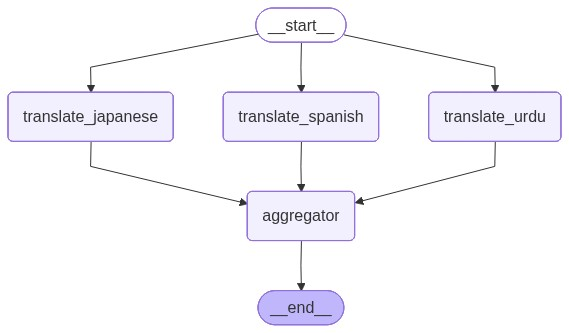

In [19]:
graph = StateGraph(State)

graph.add_node("translate_urdu", translate_urdu)
graph.add_node("translate_spanish", translate_spanish)
graph.add_node("translate_japanese", translate_japanese)
graph.add_node("aggregator", aggregator)

# Connect parallel nodes from START
graph.add_edge(START, "translate_urdu")
graph.add_edge(START, "translate_spanish")
graph.add_edge(START, "translate_japanese")

# Connect all translation nodes to the aggregator
graph.add_edge("translate_urdu", "aggregator")
graph.add_edge("translate_spanish", "aggregator")
graph.add_edge("translate_japanese", "aggregator")

# Final node
graph.add_edge("aggregator", END)

# Compile the graph
app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
input_text = {
        "text": "Good morning! I hope you have a wonderful day."
}

result = app.invoke(input_text)

In [21]:
result

{'text': 'Good morning! I hope you have a wonderful day.',
 'urdu': 'صبح بخیر! مجھے امید ہے کہ آپ کا دن شاندار گزرے گا۔',
 'spanish': '¡Buenos días! Espero que tengas un día maravilloso.',
 'japanese': 'おはようございます！素晴らしい一日になりますように。',
 'combined_output': 'Original Text: Good morning! I hope you have a wonderful day.\n\nUrdu: صبح بخیر! مجھے امید ہے کہ آپ کا دن شاندار گزرے گا۔\n\nSpanish: ¡Buenos días! Espero que tengas un día maravilloso.\n\nJapanese: おはようございます！素晴らしい一日になりますように。\n'}